In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

In [2]:
# =========================
# SETTINGS
# =========================
# Target grid (1°)
ds_out = xr.Dataset({
    "lon": (["lon"], np.arange(0, 360, 1)),
    "lat": (["lat"], np.arange(-89.5, 90.5, 1))
})

# Load mask
mask = xr.open_dataset("data/woa_grid.nc")["M3d"].isel(depth=0)

In [ ]:
# =========================
# FUNCTION
# =========================
def process_dataset(ds1, ds2, ds_out, M3d, regridder=None):
    """
    Load a POP2 dataset, regrid to 180x360, mask land, and compute phyto limitation difference.
    
    Parameters
    ----------
    ncfile : str
        Path to POP2 .nc file
    ds_out : xarray.Dataset
        Target grid (lon, lat)
    M3d : np.ndarray
        Land mask (shape ny,nx)
    regridder : xe.Regridder or None
        Pre-built regridder. If None, it will be created.
    
    Returns
    -------
    phyto_lim : np.ndarray
        3D array (ny,nx,3) with limitation codes
    regridder : xe.Regridder
        Regridder object (can reuse for multiple files)
    """

    ds = [ds1, ds2]
    
    # Build regridder if not supplied
    if regridder is None:
        ds_in_grid = xr.Dataset({"lat": ds1["TLAT"], "lon": ds1["TLONG"]})
        regridder = xe.Regridder(ds_in_grid, ds_out, method="nearest_s2d", periodic=True, reuse_weights=False)
    
    def R(ds, var):
        """Regrid and mask a variable at the top depth slice."""
        da = ds[var]

        # Determine which vertical dimension exists
        if 'z_t' in da.dims:
            zdim = 'z_t'
        elif 'z_t_150m' in da.dims:
            zdim = 'z_t_150m'
        else:
            zdim = None  # variable has no vertical dimension
        
        # Take the top slice if vertical dimension exists
        if zdim:
            v = da.isel({zdim: 0}).values  # top layer
        else:
            v = da.values  # no vertical dimension

        # Regrid
        v = regridder(v)

        # Mask inland/land
        v[v == 0] = np.nan
        v = v[0, :, :]  
        v[M3d.T[:,:] == 0] = np.nan  # transpose mask if needed

        return v
    
    # Initialize limitation array
    spN  = R(ds1, "sp_N_lim")
    ny, nx = spN.shape
    sp_lim = np.full((ny, nx, 3, 3), np.nan)
    diat_lim = np.full((ny, nx, 4, 3), np.nan)
    diaz_lim = np.full((ny, nx, 2, 3), np.nan)

    for d, dataset in enumerate(ds):
        # Small phyto
        sp_lim[:,:,0,d] = 1 - R(dataset, "sp_Fe_lim")
        sp_lim[:,:,1,d]  = 1 - R(dataset, "sp_P_lim")
        sp_lim[:,:,2,d]  = 1 - R(dataset, "sp_N_lim")

        # Diatoms
        diat_lim[:,:,0,d] = 1 - R(dataset, "diat_Fe_lim")
        diat_lim[:,:,1,d]  = 1 - R(dataset, "diat_P_lim")
        diat_lim[:,:,2,d]  = 1 - R(dataset, "diat_N_lim")
        diat_lim[:,:,3,d] = 1 - R(dataset, "diat_SiO3_lim")
        
        # Diazotrophs
        diaz_lim[:,:,0,d] = 1 - R(dataset, "diaz_Fe_lim")
        diaz_lim[:,:,1,d]  = 1 - R(dataset, "diaz_P_lim")

    sp_lim[:,:,0,2] = (sp_lim[:,:,0,0] - sp_lim[:,:,0,1])
    sp_lim[:,:,1,2]  = (sp_lim[:,:,1,0] - sp_lim[:,:,1,1])
    sp_lim[:,:,2,2]  = (sp_lim[:,:,2,0] - sp_lim[:,:,2,1])

    # Diatoms
    diat_lim[:,:,0,2] = (diat_lim[:,:,0,0] - diat_lim[:,:,0,1])
    diat_lim[:,:,1,2]  = (diat_lim[:,:,1,0] - diat_lim[:,:,1,1])
    diat_lim[:,:,2,2]  = (diat_lim[:,:,2,0] - diat_lim[:,:,2,1])
    diat_lim[:,:,3,2] = (diat_lim[:,:,3,0] - diat_lim[:,:,3,1])
    
    # Diazotrophs
    diaz_lim[:,:,0,2] = (diaz_lim[:,:,0,0] - diaz_lim[:,:,0,1])
    diaz_lim[:,:,1,2]  = (diaz_lim[:,:,1,0] - diaz_lim[:,:,1,1])
    
    return sp_lim, diat_lim, diaz_lim



In [4]:
def plot_map(data, title, filename,vmin=-0.3,vmax=0.3,vcenter=0,extend='both'):
    fig = plt.figure(figsize=(7.25, 4), dpi=300)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
    ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
    ax.set_global()
    ax.coastlines(zorder=2)

    # Gridlines and labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])
    gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = False
    gl.xlabel_style = {'size': 9, 'color': 'black'}
    gl.ylabel_style = {'size': 9, 'color': 'black'}
    gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
    gl.yformatter = LatitudeFormatter(degree_symbol='°')

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    # Plot the data
    mesh = ax.pcolormesh(
        ds_out["lon"], ds_out["lat"], data,
        shading="auto",
        transform=ccrs.PlateCarree(),
        zorder=1,
        cmap="RdBu_r",
        norm=norm
    )
    
    # Add colorbar
    cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, extend=extend)
    cbar.set_label(title)

    ax.set_rasterization_zorder(1)

    plt.savefig(filename, dpi=600, bbox_inches='tight',
            transparent=False)


/tmp/ipykernel_1268299/2580923482.py:5: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds1 = xr.open_dataset("data/gdev1420.pop.h.0281_0300.nc")
/tmp/ipykernel_1268299/2580923482.py:6: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's defaul

All datasets processed.


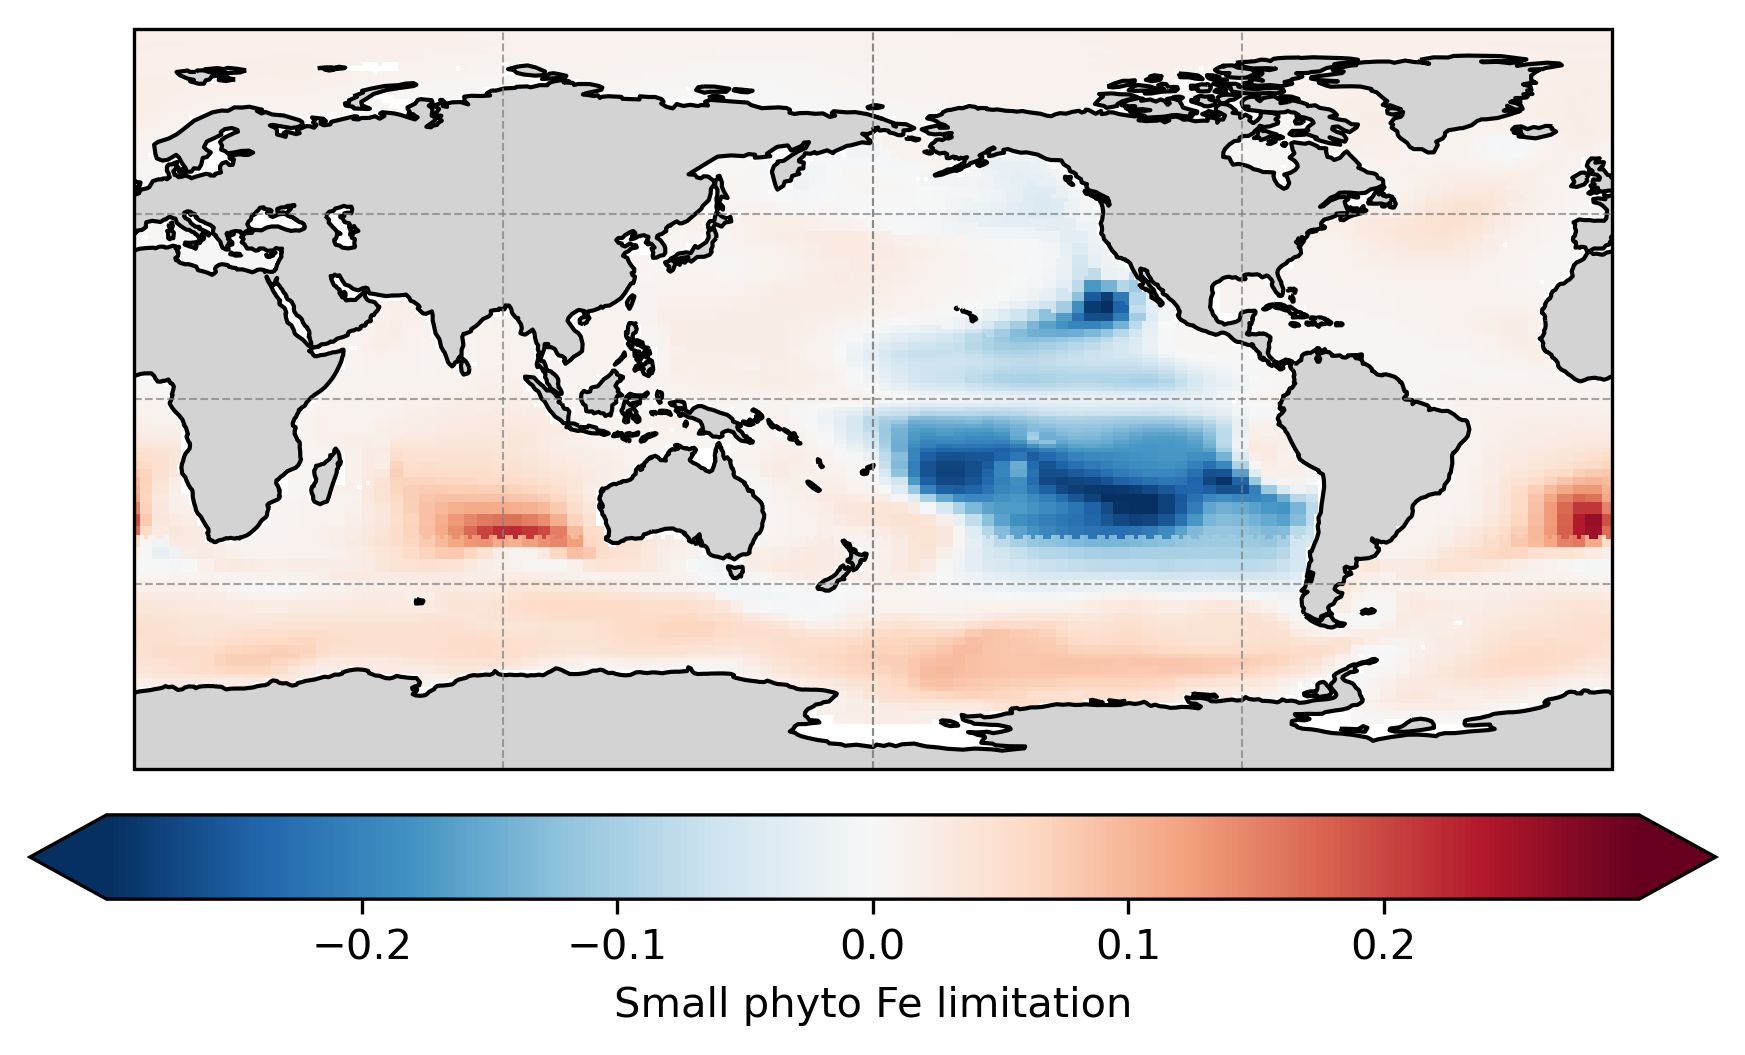

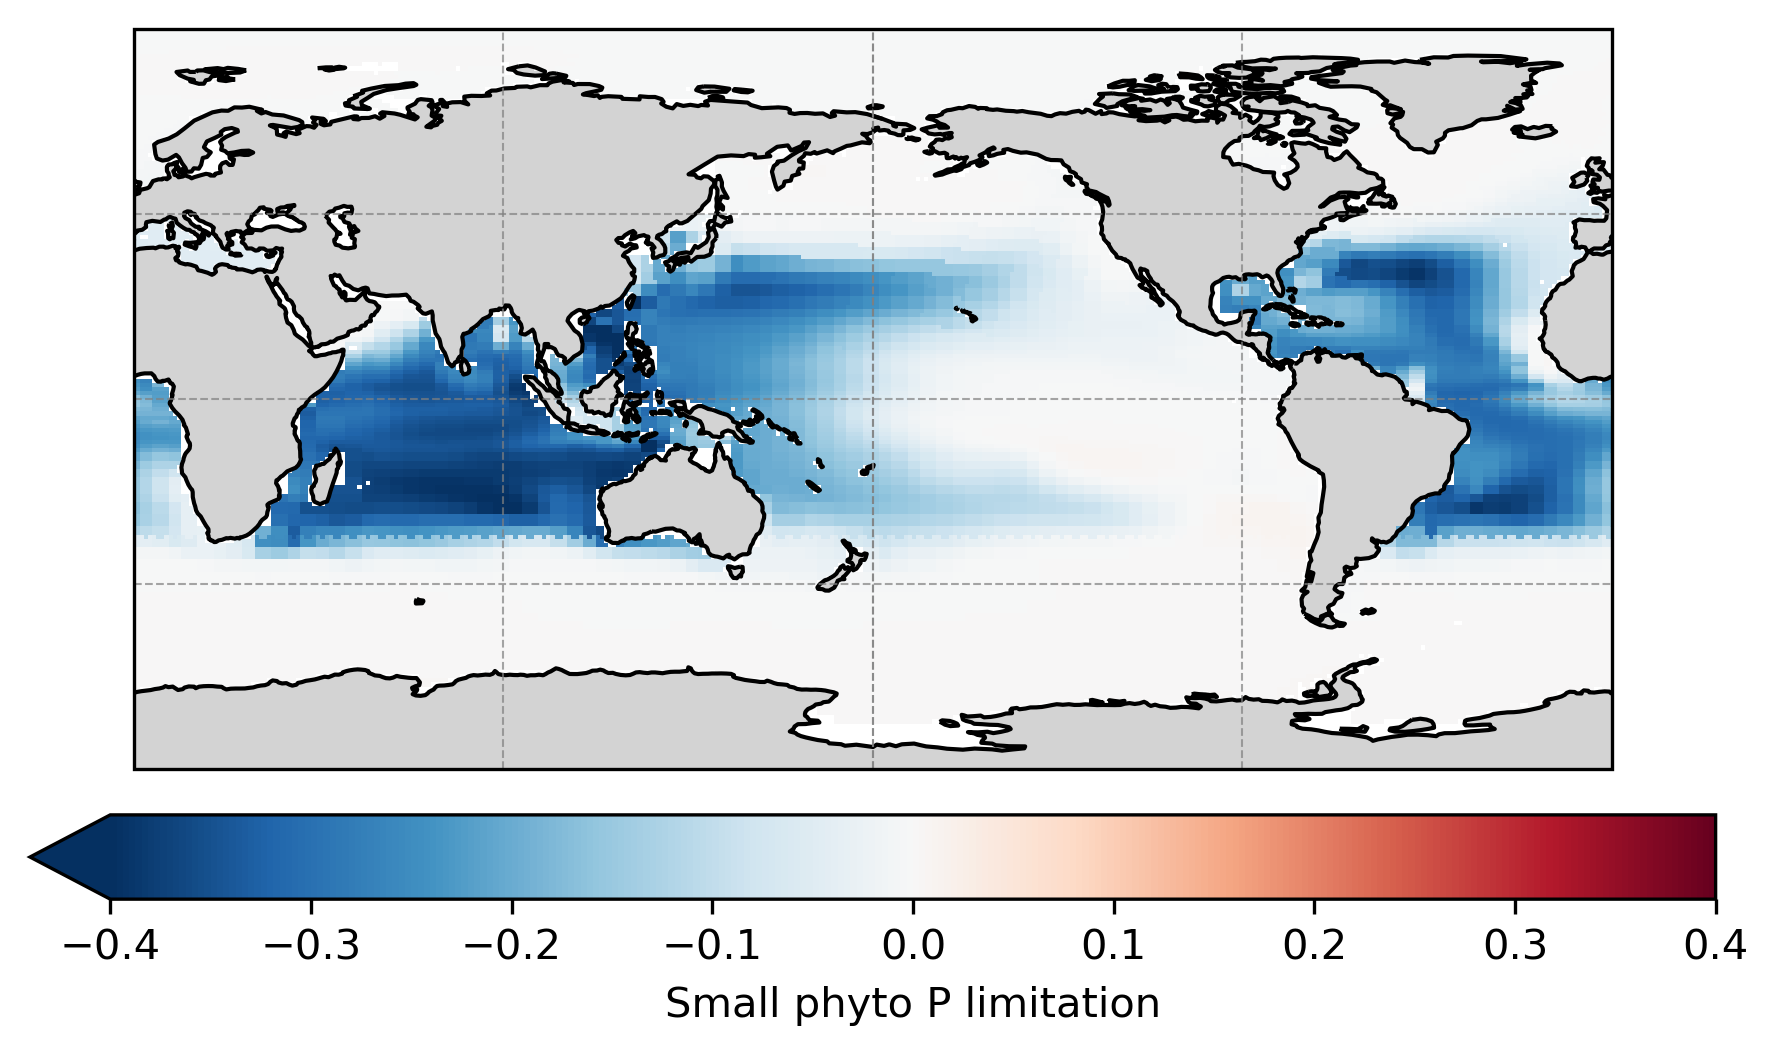

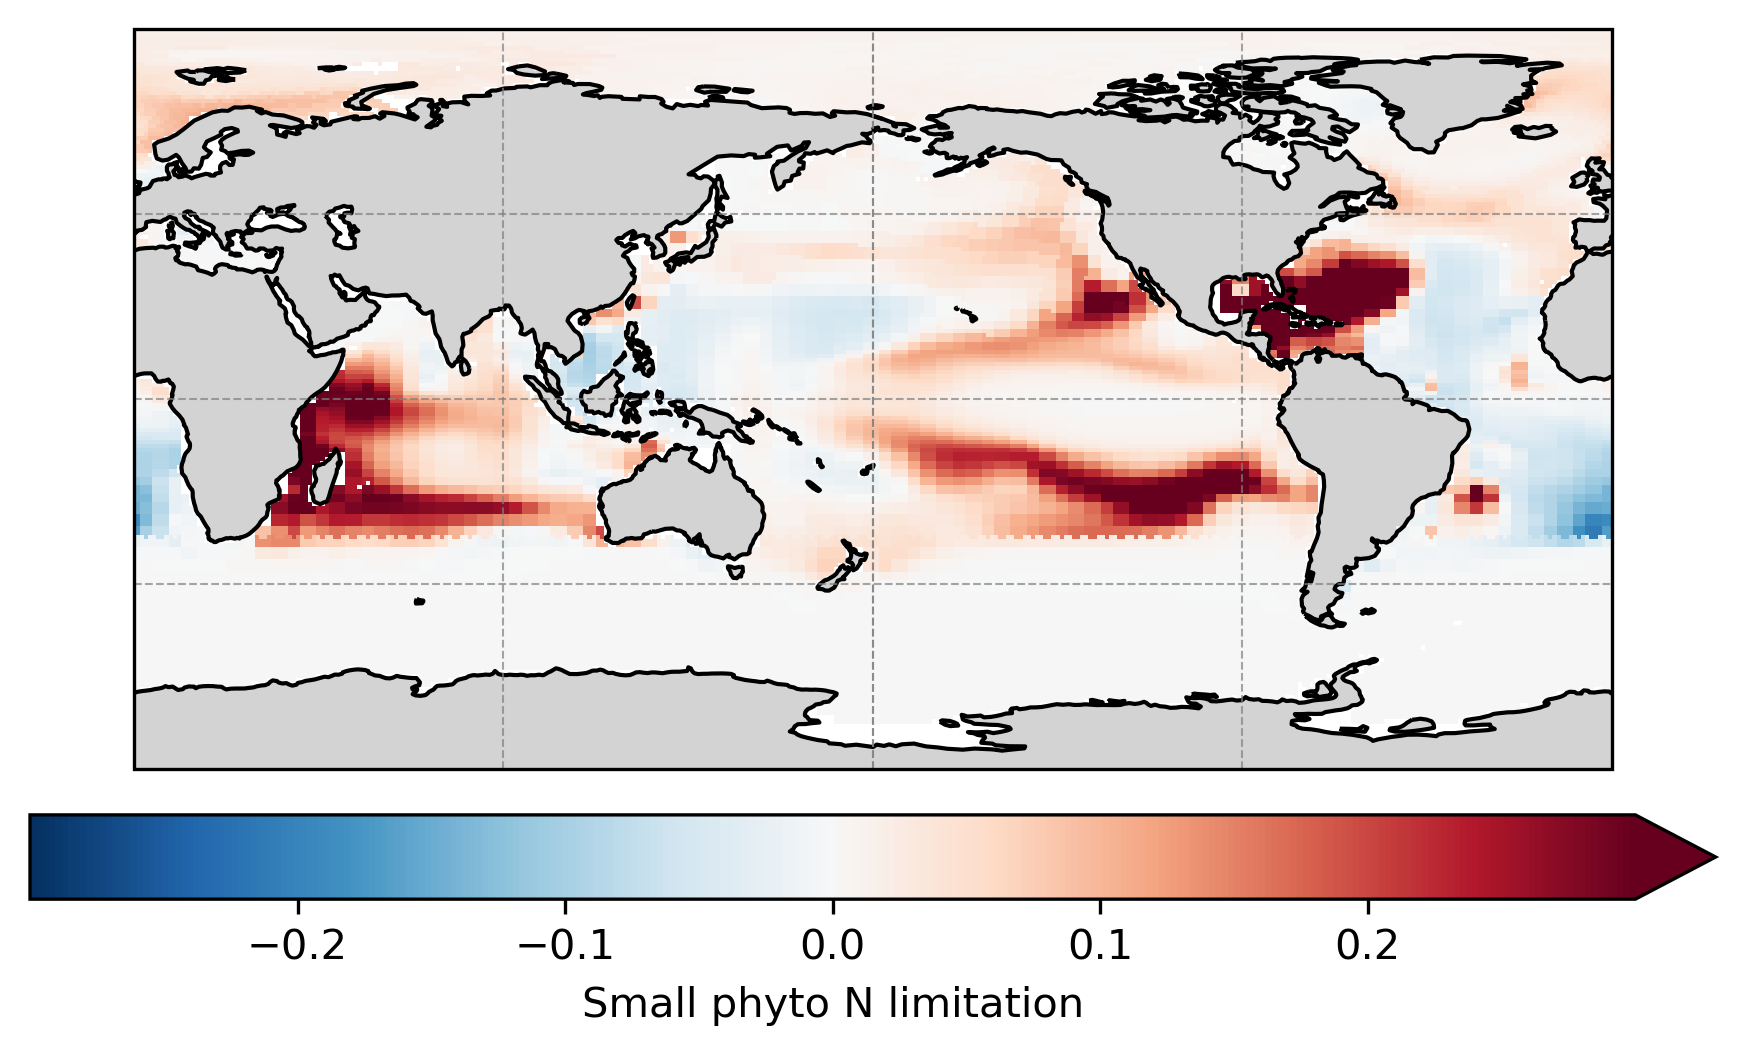

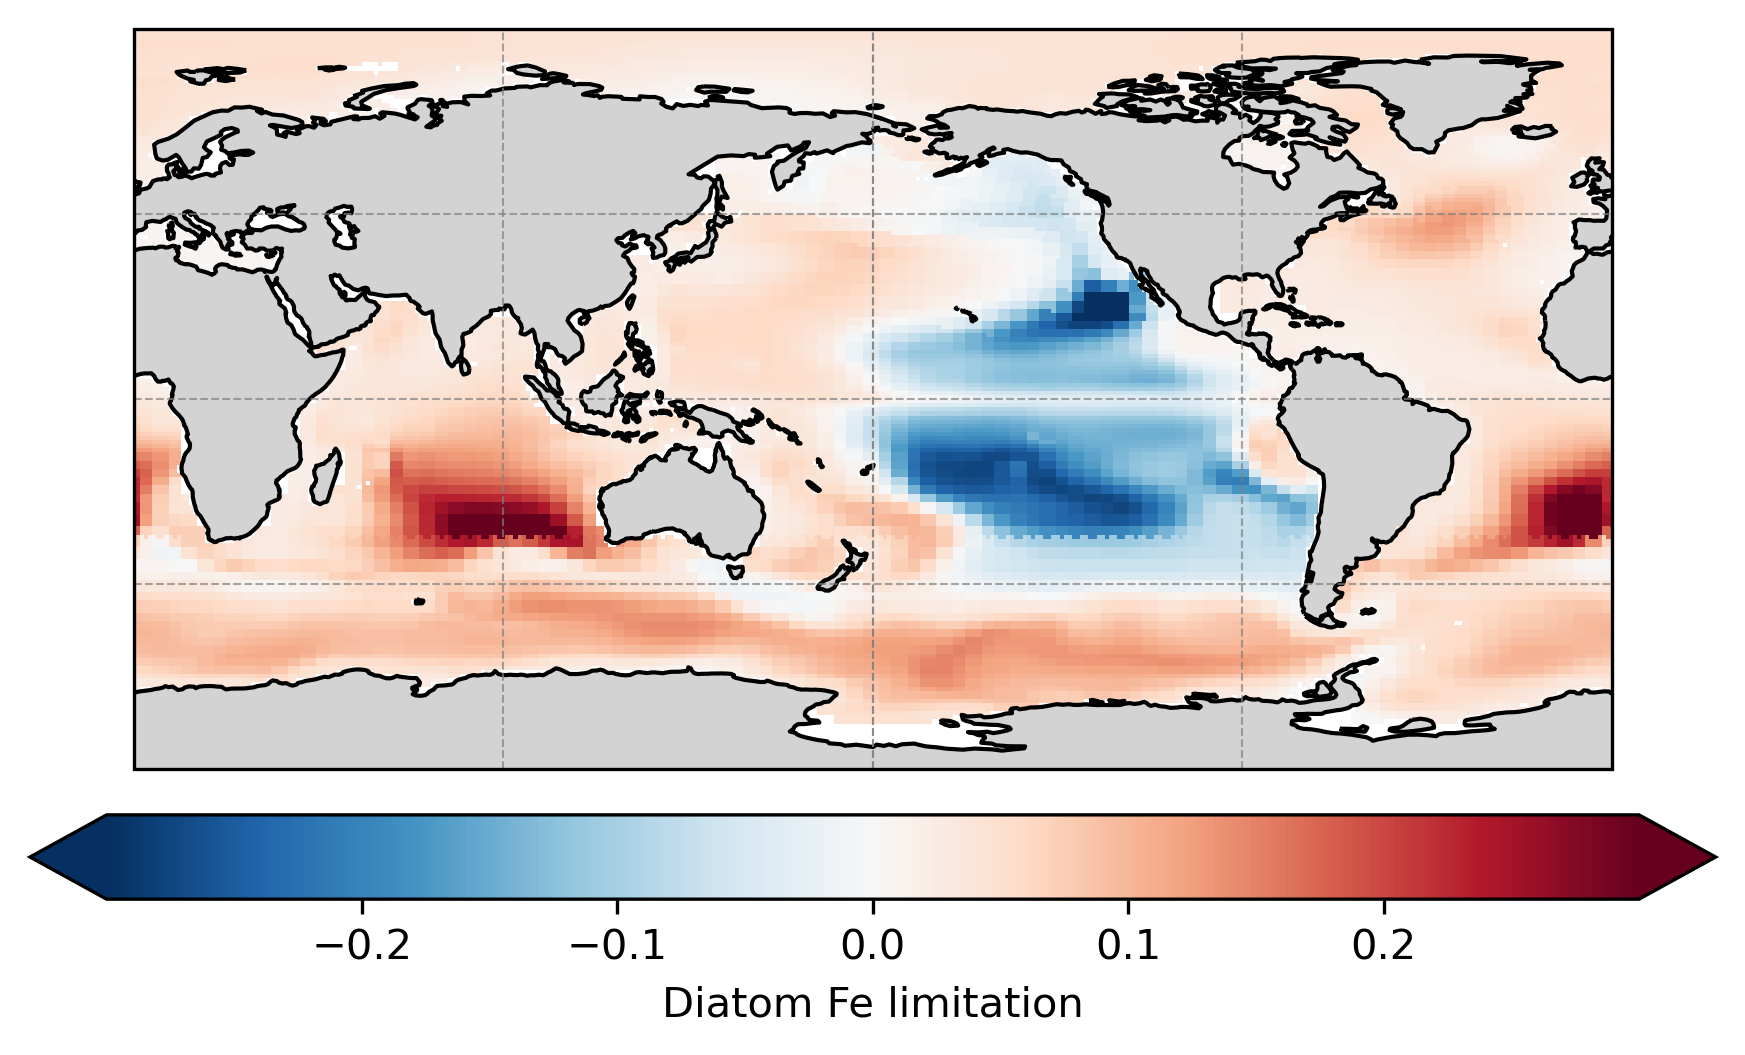

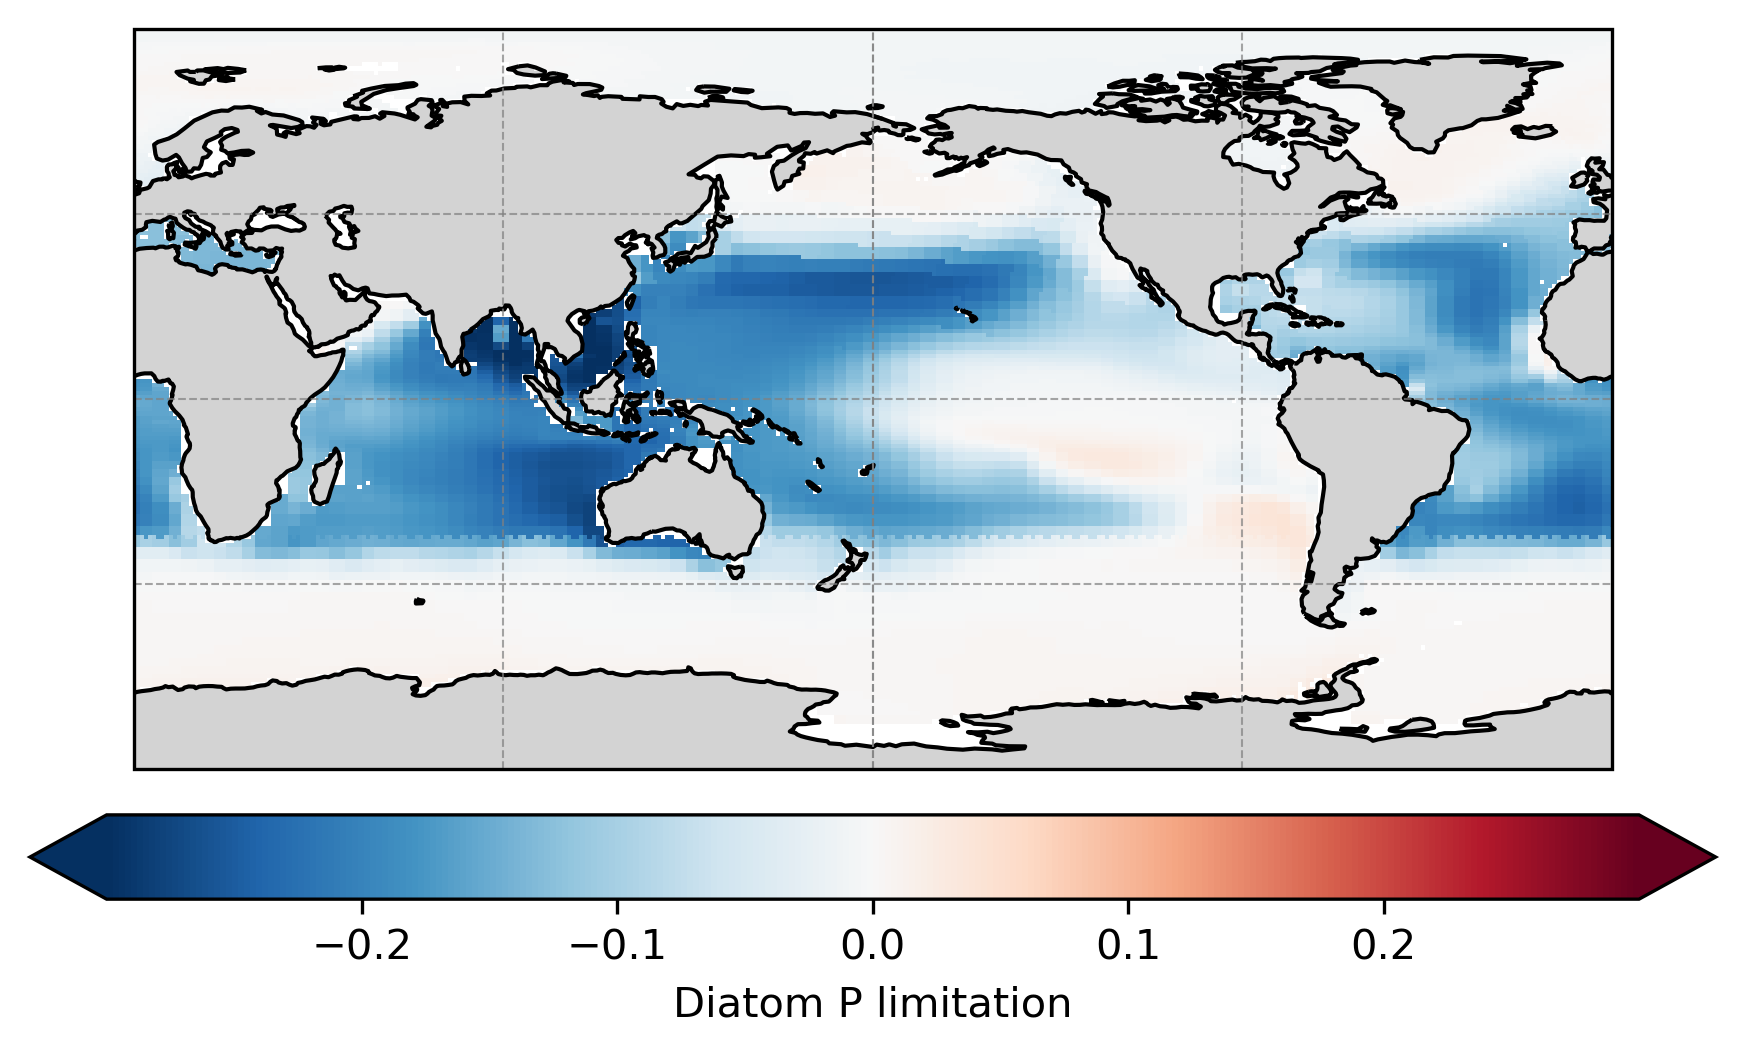

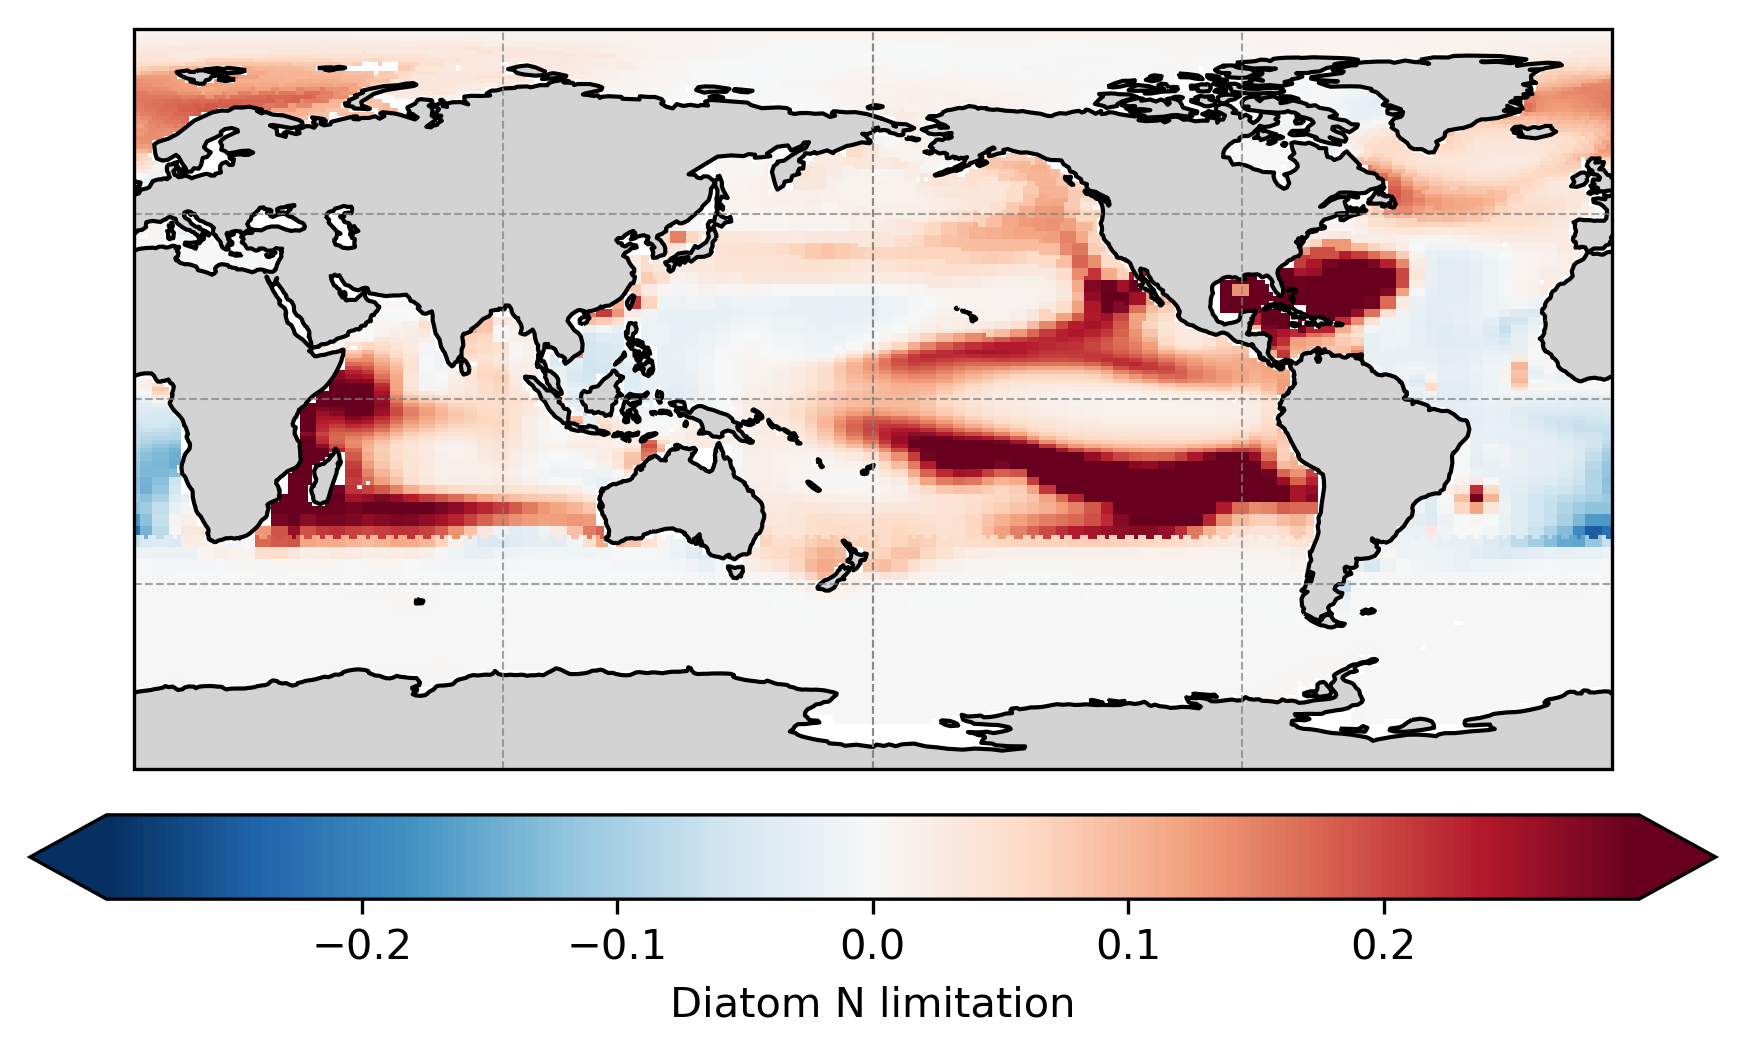

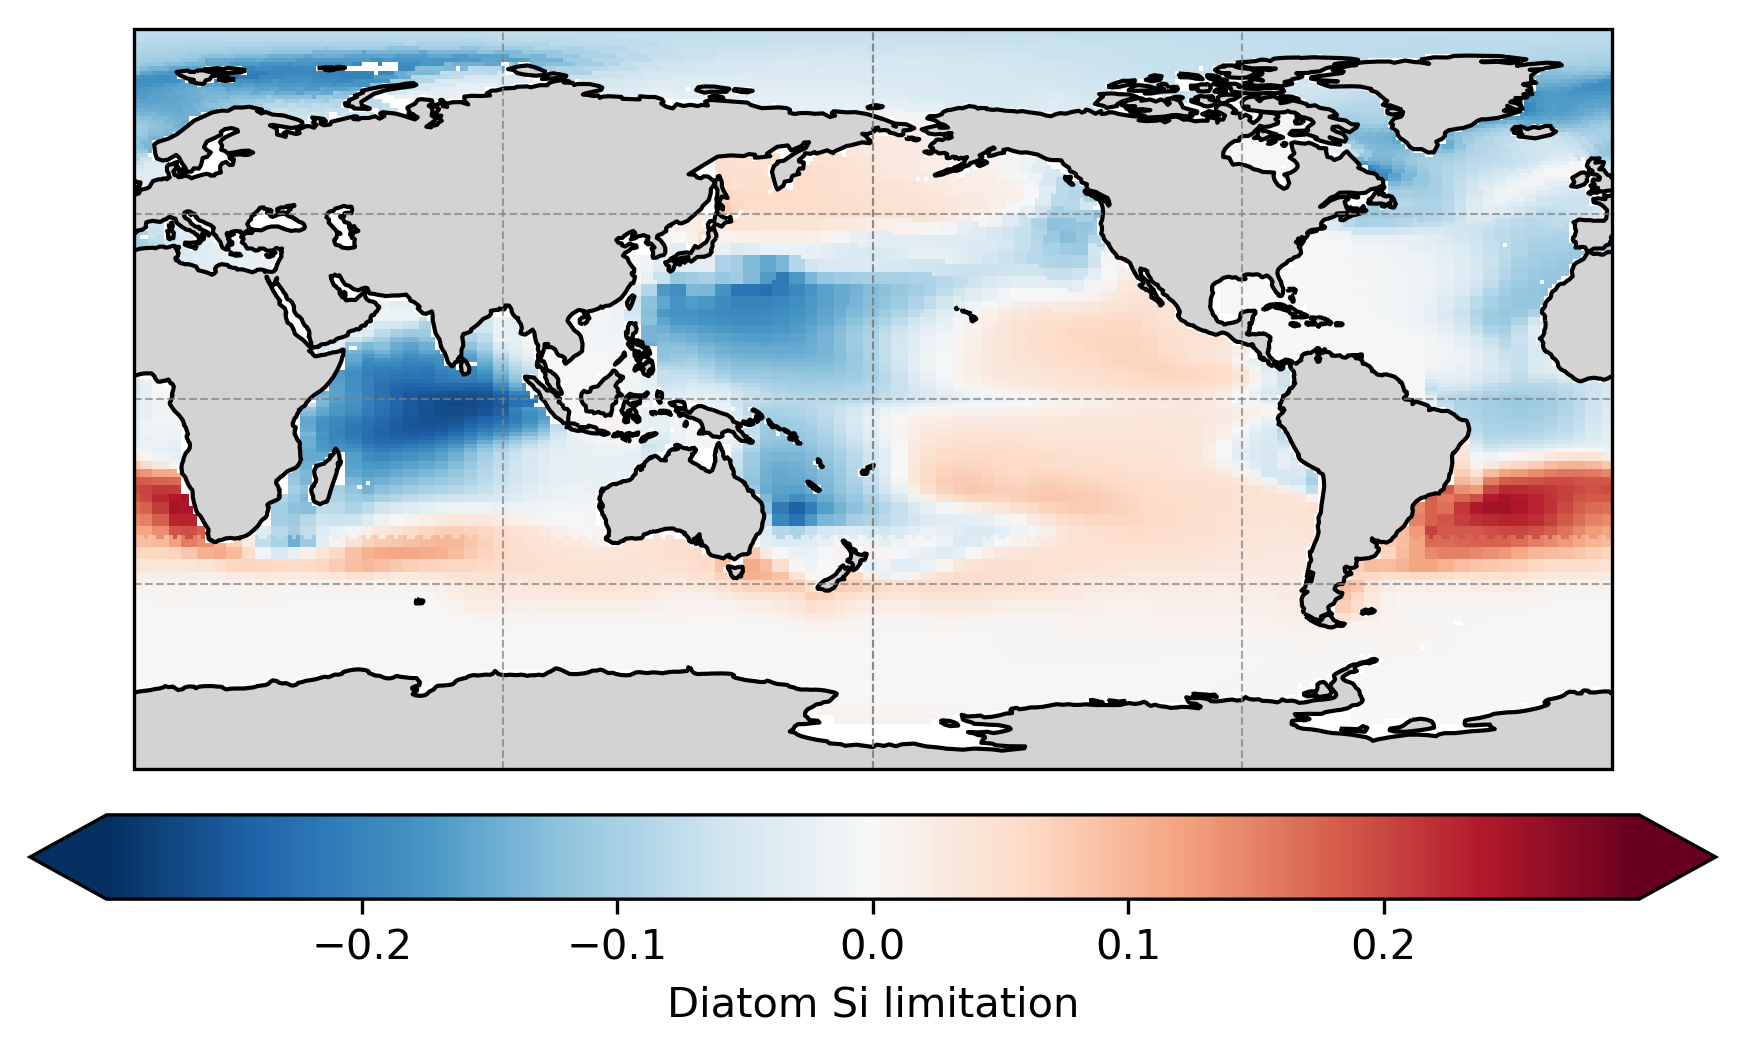

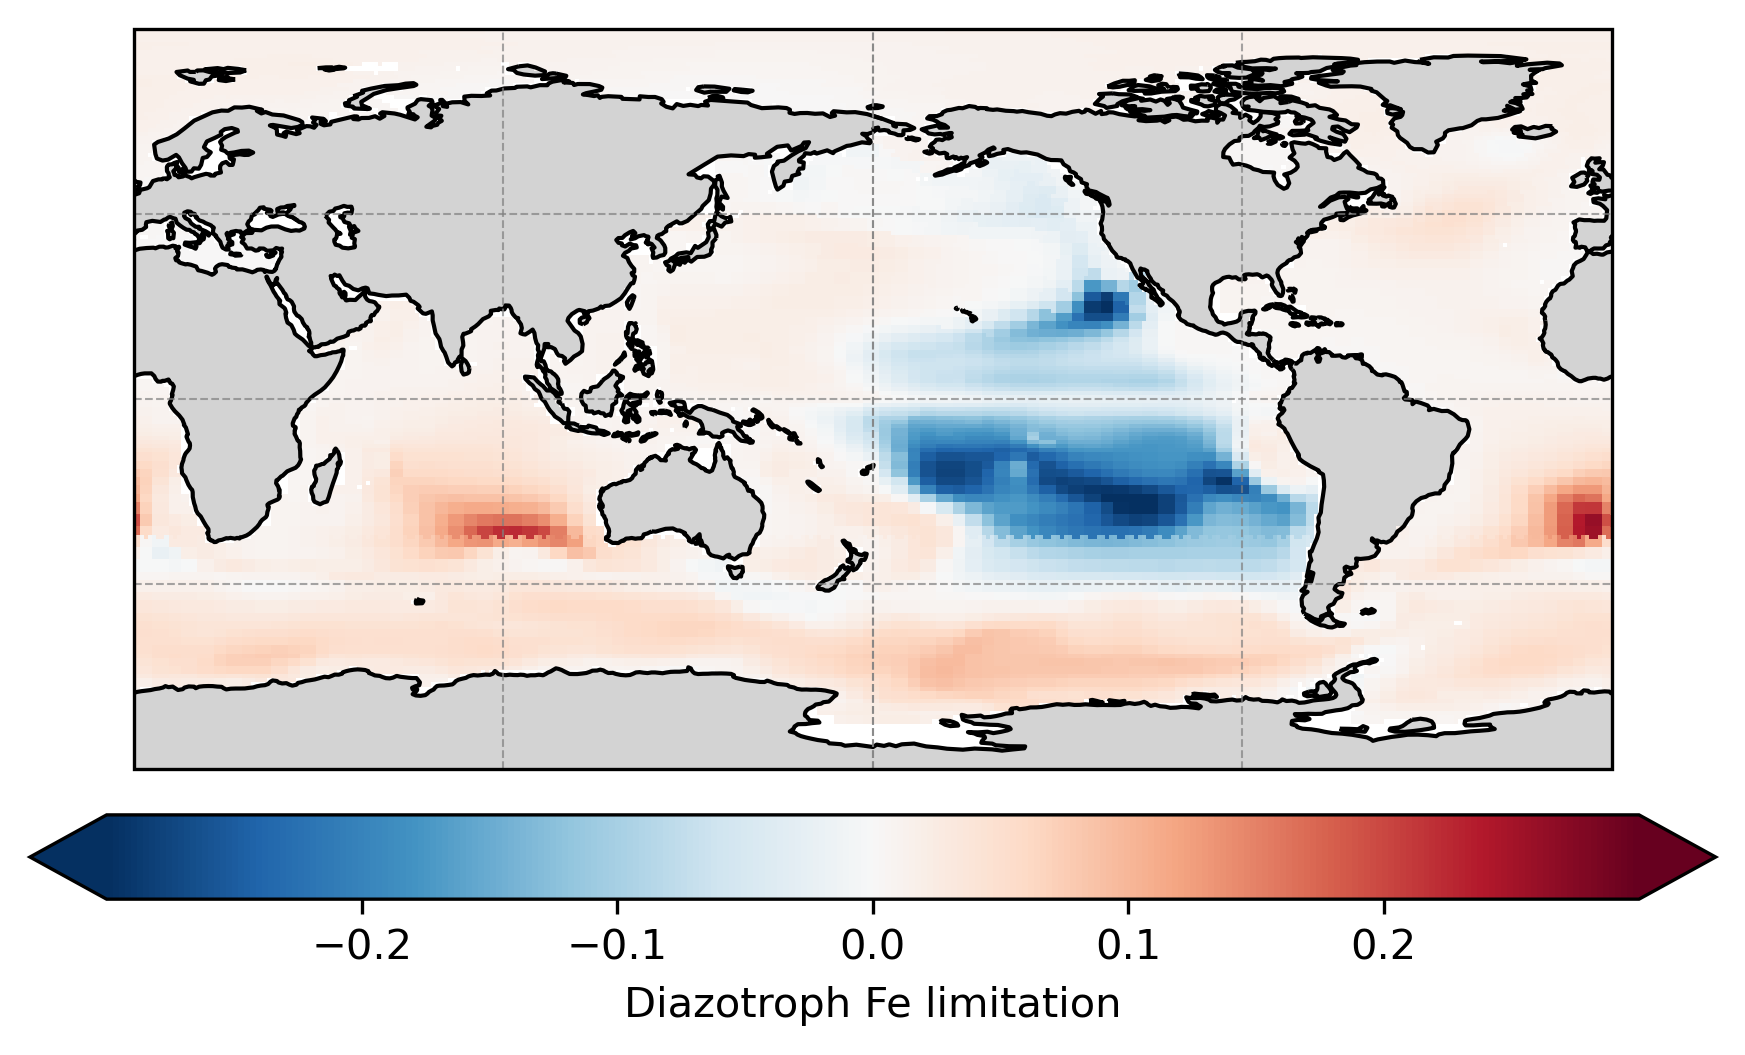

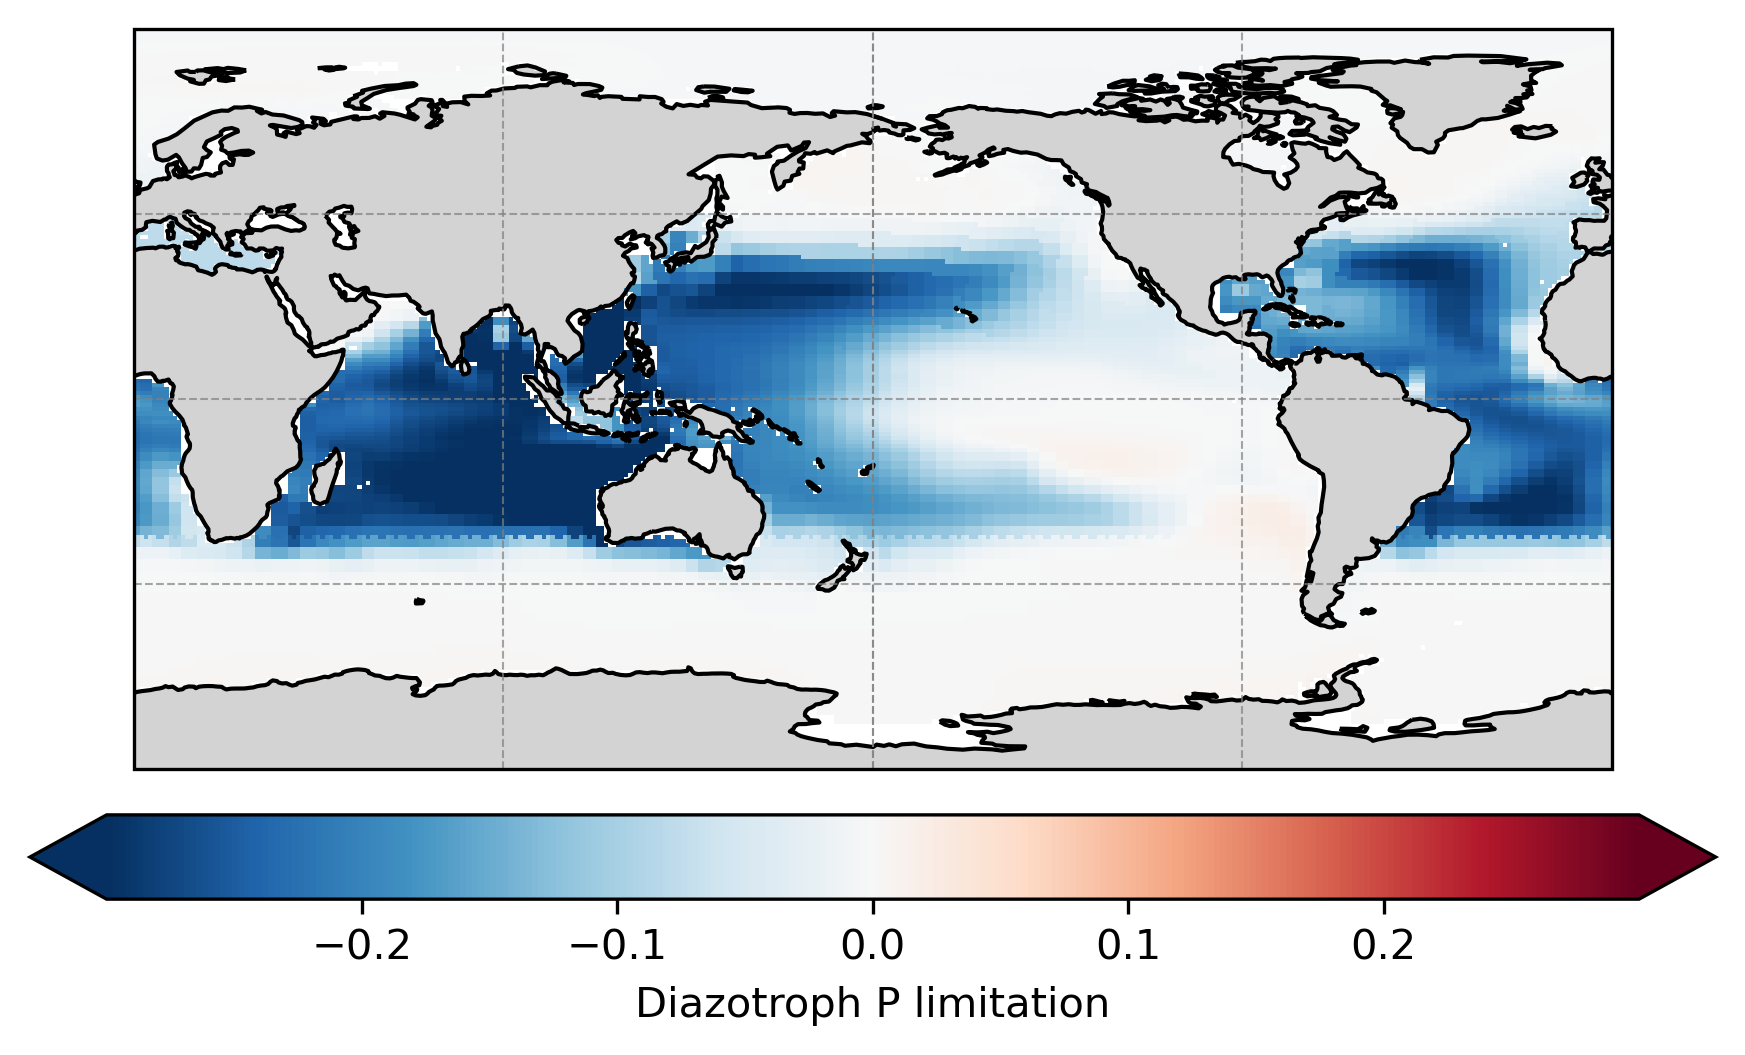

In [5]:
# =========================
# MAIN
# =========================

ds1 = xr.open_dataset("data/gdev1420.pop.h.0281_0300.nc")
ds2 = xr.open_dataset("data/gdev1440.pop.h.0281_0300.nc")

regridder = None

sp_lim, diat_lim, diaz_lim = process_dataset(ds1, ds2, ds_out, mask, regridder)

name = 'gdev1420-gdev1440.pop.h.0281_0300'

plot_map(sp_lim[:,:,0,2], "Small phyto Fe limitation", f"figures/{name}_spFelim.svg")
plot_map(sp_lim[:,:,1,2], "Small phyto P limitation", f"figures/{name}_spPlim.svg",vmin=-0.4,vmax=0.4,extend='min')
plot_map(sp_lim[:,:,2,2], "Small phyto N limitation", f"figures/{name}_spNlim.svg",extend='max')

plot_map(diat_lim[:,:,0,2], "Diatom Fe limitation", f"figures/{name}_diatFelim.svg")
plot_map(diat_lim[:,:,1,2], "Diatom P limitation", f"figures/{name}_diatPlim.svg")
plot_map(diat_lim[:,:,2,2], "Diatom N limitation", f"figures/{name}_diatNlim.svg")
plot_map(diat_lim[:,:,3,2], "Diatom Si limitation", f"figures/{name}_diatSilim.svg")

plot_map(diaz_lim[:,:,0,2], "Diazotroph Fe limitation", f"figures/{name}_diazFelim.svg")
plot_map(diaz_lim[:,:,1,2], "Diazotroph P limitation", f"figures/{name}_diazPlim.svg")

print("All datasets processed.")